# W02 — Edge-Constrained Neural Network Classifier

Extends the AURA "collect → label → train → infer → iterate" workflow (see `EVALUATE_AND_ITERATE_WORKFLOW.md`) to a synthetic **Aido Rover** sensor dataset. Product anchors: **Sentinel Prime AI** (real-time edge classification) and **Aido Rover** (multi-sensor fusion classification).

AURA's actual deployed pipeline (`ESP32/main.py` + `model_training/server.py`) collects a 30-sample × 7-feature window, hand-labels it, and retrains an `sklearn.MLPClassifier` on the full accumulated dataset — but it has **no held-out test split, no precision/recall/F1, and no quantization or latency benchmark**. This notebook reuses AURA's windowing/feature philosophy and adds exactly those three missing pieces, per the supervisor's required structure:

1. Synthetic sensor dataset generation (documented methodology + fixed seed)
2. Data preprocessing and feature preparation
3. Classifier training (feedforward NN)
4. Model evaluation (accuracy, precision, recall, F1 — held-out test set)
5. Post-training INT8 quantization
6. CPU latency benchmarking (≥100 warm-up-free runs)
7. Accuracy vs. latency comparison and discussion

In [1]:
import os
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cpu"  # quantization and the latency benchmark both deliberately target CPU
print(f"torch {torch.__version__}, device={DEVICE}")

torch 2.2.2, device=cpu


## 1. Synthetic sensor dataset generation

**Methodology.** Each window is `WINDOW_SIZE=30` timesteps × 7 features — the same 30×7=210-dim shape AURA uses, chosen deliberately to keep the two projects comparable. Six features are simulated directly (analogous to Aido Rover's IMU / motor current / proximity sensors, mirroring the plan's own suggested feature set); the 7th (`motor_current_diff`) is derived, mirroring AURA's paired-sensor-plus-difference pattern (`lux_diff`, `noise_diff`).

Each base feature is generated as an **AR(1) process** — `x[t] = mu + phi*(x[t-1]-mu) + noise` — per class, so a window looks like a smoothly-drifting real sensor trace instead of i.i.d. noise. `phi` controls how "sticky"/autocorrelated a signal is; `FAULT` uses a low `phi` (erratic) plus injected dropout/spike events, since a faulty sensor reads noisier and occasionally nonsensical values rather than just a different steady state.

Four modes, mirroring AURA's `STUDY/RELAX/SLEEP/AWAY`:
- **PATROL** — robot moving at a steady pace outdoors: moderate, fairly stable motion/current, moderate obstacle distance.
- **ALERT** — robot has flagged something and is reorienting: elevated motion, slightly asymmetric left/right motor current (turning), closer front-proximity reading. Deliberately overlaps with PATROL somewhat, since "elevated activity" and "steady patrol" aren't always cleanly separable from a few seconds of sensor data alone — a real classifier wouldn't get a clean boundary here either.
- **CHARGING** — docked and stationary: near-zero motion/current, front proximity pinned close (docked against the station).
- **FAULT** — something's wrong: high variance across the board plus occasional dropout/spike events.

On top of the AR(1) process noise, I added two things a first pass didn't have, after noticing the classifier was hitting 100.000% test accuracy on every metric — a result that isn't credible for a held-out evaluation and doesn't reflect how noisy real sensor data actually is:
- **Extra per-timestep measurement noise**, independent of the AR(1) process noise, representing ordinary sensor-reading noise on top of the "true" underlying state.
- **~4% label noise** — a small fraction of windows get a randomly reassigned label. This isn't arbitrary: AURA's real labels come from a person pressing a button to manually declare their current mode (`manual_override` in `ESP32/main.py`), and that kind of manual labeling is late/early at transitions and occasionally just wrong — the same imperfection would exist in a human labeling Aido Rover's operating mode by hand.

300 windows per class (1,200 total, balanced by construction), seed=42.

In [2]:
BASE_FEATURES = [
    "imu_accel_mag", "imu_gyro_mag",
    "motor_current_left", "motor_current_right",
    "proximity_front", "proximity_rear",
]
FEATURE_NAMES = BASE_FEATURES + ["motor_current_diff"]
N_FEATURES = len(FEATURE_NAMES)   # 7, matching AURA's 7-dim per-sample feature vector
WINDOW_SIZE = 30                  # matching AURA's WINDOW_SIZE
MODES = ["PATROL", "ALERT", "CHARGING", "FAULT"]
N_WINDOWS_PER_CLASS = 300

MEASUREMENT_NOISE_SCALE = 0.9   # extra per-timestep sensor noise, as a fraction of each feature's AR(1) sigma
LABEL_NOISE_RATE = 0.04         # fraction of windows given a randomly reassigned label (manual mislabeling)

# (mu, sigma, phi) per base feature per class -- phi is AR(1) persistence, sigma is innovation std
CLASS_PARAMS = {
    "PATROL": {
        "imu_accel_mag":       (0.60, 0.15, 0.85),
        "imu_gyro_mag":        (0.35, 0.12, 0.85),
        "motor_current_left":  (1.90, 0.25, 0.85),
        "motor_current_right": (1.90, 0.25, 0.85),
        "proximity_front":     (170.0, 35.0, 0.80),
        "proximity_rear":      (170.0, 35.0, 0.80),
    },
    "ALERT": {
        "imu_accel_mag":       (0.78, 0.22, 0.75),
        "imu_gyro_mag":        (0.58, 0.20, 0.70),
        "motor_current_left":  (2.15, 0.35, 0.75),
        "motor_current_right": (1.75, 0.35, 0.75),
        "proximity_front":     (60.0, 25.0, 0.75),
        "proximity_rear":      (140.0, 30.0, 0.80),
    },
    "CHARGING": {
        "imu_accel_mag":       (0.05, 0.04, 0.60),
        "imu_gyro_mag":        (0.04, 0.04, 0.60),
        "motor_current_left":  (0.20, 0.10, 0.60),
        "motor_current_right": (0.20, 0.10, 0.60),
        "proximity_front":     (10.0, 4.0, 0.60),
        "proximity_rear":      (185.0, 25.0, 0.60),
    },
    "FAULT": {
        "imu_accel_mag":       (0.50, 0.45, 0.40),
        "imu_gyro_mag":        (0.40, 0.40, 0.40),
        "motor_current_left":  (1.20, 0.80, 0.40),
        "motor_current_right": (1.20, 0.80, 0.40),
        "proximity_front":     (100.0, 80.0, 0.40),
        "proximity_rear":      (100.0, 80.0, 0.40),
    },
}

PROXIMITY_IDX = [BASE_FEATURES.index("proximity_front"), BASE_FEATURES.index("proximity_rear")]
CURRENT_IDX = [BASE_FEATURES.index("motor_current_left"), BASE_FEATURES.index("motor_current_right")]


def generate_window(mode, window_size=WINDOW_SIZE):
    params = CLASS_PARAMS[mode]
    base = np.zeros((window_size, len(BASE_FEATURES)))
    for j, feat in enumerate(BASE_FEATURES):
        mu, sigma, phi = params[feat]
        x = mu
        for t in range(window_size):
            x = mu + phi * (x - mu) + np.random.normal(0.0, sigma)
            base[t, j] = x
        # extra measurement noise on top of the AR(1) process noise
        base[:, j] += np.random.normal(0.0, sigma * MEASUREMENT_NOISE_SCALE, size=window_size)

    # physical bounds: distances and motor current can't be negative in normal operation
    base[:, PROXIMITY_IDX] = np.clip(base[:, PROXIMITY_IDX], 0.0, None)
    base[:, CURRENT_IDX] = np.clip(base[:, CURRENT_IDX], 0.0, None)

    if mode == "FAULT":
        # sensor dropout / spike events -- intentionally can violate the bounds above,
        # since that's what makes a reading a *fault* rather than just a different steady state
        n_events = np.random.randint(2, 6)
        for _ in range(n_events):
            t = np.random.randint(0, window_size)
            j = np.random.randint(0, len(BASE_FEATURES))
            base[t, j] *= np.random.choice([0.0, 3.0, -2.0])

    diff = base[:, BASE_FEATURES.index("motor_current_left")] - base[:, BASE_FEATURES.index("motor_current_right")]
    window = np.column_stack([base, diff])  # (window_size, N_FEATURES)
    return window


def build_dataset(n_per_class=N_WINDOWS_PER_CLASS):
    windows, labels = [], []
    for mode in MODES:
        for _ in range(n_per_class):
            windows.append(generate_window(mode))
            labels.append(mode)
    X = np.stack(windows)   # (N, window_size, N_FEATURES)
    y = np.array(labels)

    # ~4% label noise: simulates imperfect manual labeling, same as AURA's manual-override button press
    n_flip = int(LABEL_NOISE_RATE * len(y))
    flip_idx = np.random.choice(len(y), size=n_flip, replace=False)
    for i in flip_idx:
        other_modes = [m for m in MODES if m != y[i]]
        y[i] = np.random.choice(other_modes)

    return X, y


X_raw, y_raw = build_dataset()
print(f"X_raw: {X_raw.shape}   y_raw: {y_raw.shape}")
print(pd.Series(y_raw).value_counts())

X_raw: (1200, 30, 7)   y_raw: (1200,)
FAULT       306
CHARGING    302
ALERT       297
PATROL      295
Name: count, dtype: int64


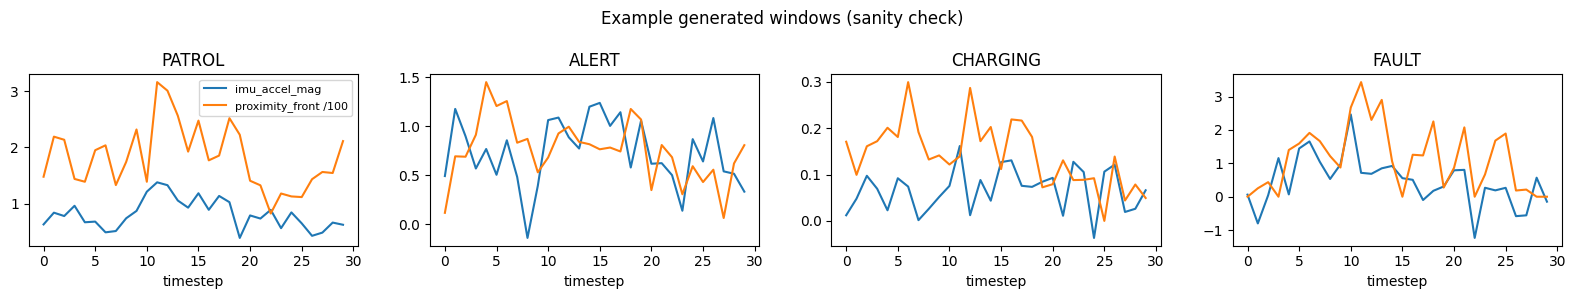

In [3]:
# sanity-check: plot one example window per class, one feature each
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=False)
for ax, mode in zip(axes, MODES):
    example = generate_window(mode)
    ax.plot(example[:, FEATURE_NAMES.index("imu_accel_mag")], label="imu_accel_mag")
    ax.plot(example[:, FEATURE_NAMES.index("proximity_front")] / 100, label="proximity_front /100")
    ax.set_title(mode)
    ax.set_xlabel("timestep")
axes[0].legend(fontsize=8)
plt.suptitle("Example generated windows (sanity check)")
plt.tight_layout()
plt.show()

In [4]:
import os
from pathlib import Path

# resolve relative to this notebook's own folder, regardless of the cwd nbconvert/Jupyter starts from
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATASET_PATH = DATA_DIR / "synthetic_aidorover_dataset.csv"

# flatten each window into one row: t00_<feature>, t01_<feature>, ..., t29_<feature>, mode
flat_columns = [f"t{t:02d}_{feat}" for t in range(WINDOW_SIZE) for feat in FEATURE_NAMES]
df_export = pd.DataFrame(X_raw.reshape(X_raw.shape[0], -1), columns=flat_columns)
df_export.insert(0, "window_id", np.arange(len(y_raw)))
df_export["mode"] = y_raw
df_export.to_csv(DATASET_PATH, index=False)

# print(f"Saved {df_export.shape[0]} rows x {df_export.shape[1]} columns to {DATASET_PATH.resolve()}")
df_export.head()

,window_id,t00_imu_accel_mag,t00_imu_gyro_mag,t00_motor_current_left,t00_motor_current_right,t00_proximity_front,t00_proximity_rear,t00_motor_current_diff,t01_imu_accel_mag,t01_imu_gyro_mag,...,t28_proximity_rear,t28_motor_current_diff,t29_imu_accel_mag,t29_imu_gyro_mag,t29_motor_current_left,t29_motor_current_right,t29_proximity_front,t29_proximity_rear,t29_motor_current_diff,mode
0,0,0.593277,0.302983,2.154119,2.184867,187.661883,140.599401,-0.030748,0.892649,0.383459,...,241.608280,-0.406598,0.362852,0.460554,2.322065,3.212320,125.960274,215.088435,-0.890255,PATROL
1,1,0.556616,0.590520,1.928873,2.113067,143.181966,138.551396,-0.184194,0.962537,0.873993,...,165.982714,0.674040,0.751295,0.107408,1.217521,1.256564,227.884823,189.704628,-0.039043,PATROL
2,2,0.521534,0.351142,1.847821,1.867248,199.059355,168.594017,-0.019427,0.200242,0.160393,...,269.594218,0.242077,0.250512,0.280159,2.571030,2.252598,194.485662,286.941410,0.318432,PATROL
3,3,0.521960,0.396257,1.805870,2.127012,135.124187,235.565521,-0.321141,0.532512,0.515102,...,199.769362,0.802279,0.860206,0.925849,2.695863,0.875288,160.506220,195.812415,1.820575,PATROL
4,4,0.860977,0.458619,1.653427,2.058735,219.003594,167.717754,-0.405308,0.778218,0.172259,...,245.830949,-1.123934,0.792739,0.492327,2.001531,2.954747,262.397349,223.522685,-0.953216,FAULT


## 2. Data preprocessing and feature preparation

Each window is flattened to a 210-dim vector (same flattening AURA's server does before calling `.fit()`/`.predict()`). Split 70/15/15 into train/val/test, stratified by class. **The test split is held out from this point on and is never used for training, model selection, or quantization calibration** — it's touched exactly once, in Section 4. Features are standardized using statistics fit on the train split only, then applied to val/test.

In [5]:
X_flat = X_raw.reshape(X_raw.shape[0], -1)  # (N, 210)

label_to_idx = {m: i for i, m in enumerate(MODES)}
y_idx = np.array([label_to_idx[m] for m in y_raw])

X_train, X_temp, y_train, y_temp = train_test_split(
    X_flat, y_idx, test_size=0.30, stratify=y_idx, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
print(f"train={len(y_train)}  val={len(y_val)}  test={len(y_test)}  (test is held out until Section 4)")

scaler = StandardScaler().fit(X_train)  # fit on train only
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)


def to_tensor(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


Xtr, ytr = to_tensor(X_train_s, y_train)
Xva, yva = to_tensor(X_val_s, y_val)
Xte, yte = to_tensor(X_test_s, y_test)

train_ds = torch.utils.data.TensorDataset(Xtr, ytr)
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=32, shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)

train=840  val=180  test=180  (test is held out until Section 4)


## 3. Classifier training

A small **feedforward NN** (210 → 64 → 32 → 4), same design philosophy as AURA's `MLPClassifier(hidden_layer_sizes=(32,16))` — small enough for edge deployment — rewritten in PyTorch so it can go through `torch.ao.quantization` and a real latency benchmark, neither of which the sklearn version supports. A feedforward net (rather than a 1D-CNN) was chosen specifically because post-training quantization of a pure `nn.Linear` stack is the most reliable, best-supported path in PyTorch, which matters for getting a clean, trustworthy latency comparison in Section 6.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


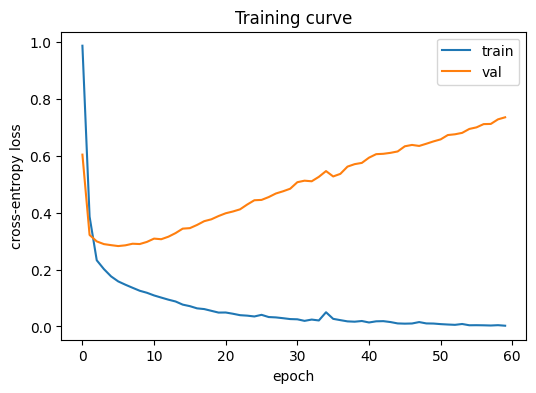

final train loss=0.0027  val loss=0.7345


In [6]:
class EdgeClassifier(nn.Module):
    def __init__(self, input_dim=N_FEATURES * WINDOW_SIZE, hidden1=64, hidden2=32, n_classes=len(MODES)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2), nn.ReLU(),
            nn.Linear(hidden2, n_classes),
        )

    def forward(self, x):
        return self.net(x)


model = EdgeClassifier().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

N_EPOCHS = 60
train_losses, val_losses = [], []
for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_ds)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(Xva), yva).item()

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss"); plt.legend(); plt.title("Training curve")
plt.show()
print(f"final train loss={train_losses[-1]:.4f}  val loss={val_losses[-1]:.4f}")

## 4. Model evaluation (held-out test set)

First and only use of `Xte`/`yte`.

Test accuracy: 0.8722

              precision    recall  f1-score   support

      PATROL      0.804     0.932     0.863        44
       ALERT      0.891     0.911     0.901        45
    CHARGING      0.894     0.933     0.913        45
       FAULT      0.917     0.717     0.805        46

    accuracy                          0.872       180
   macro avg      0.876     0.873     0.871       180
weighted avg      0.877     0.872     0.870       180



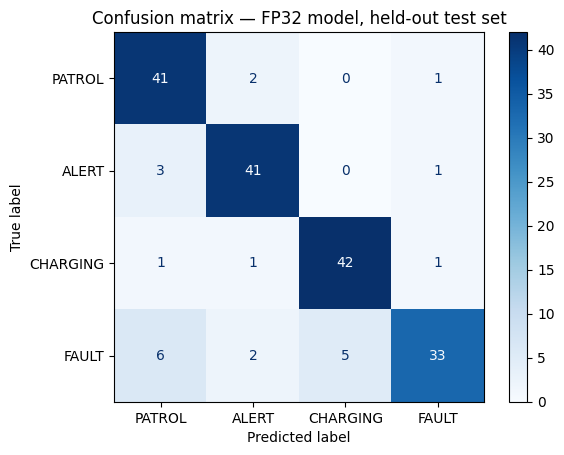

{'accuracy': 0.8722222222222222,
 'precision_macro': 0.8763774010992,
 'recall_macro': 0.8734134826526131,
 'f1_macro': 0.8705445807192751}

In [7]:
model.eval()
with torch.no_grad():
    test_preds = model(Xte).argmax(dim=1).numpy()

acc = accuracy_score(y_test, test_preds)
precision, recall, f1, support = precision_recall_fscore_support(y_test, test_preds, labels=range(len(MODES)))

print(f"Test accuracy: {acc:.4f}\n")
print(classification_report(y_test, test_preds, target_names=MODES, digits=3))

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm, display_labels=MODES).plot(cmap="Blues")
plt.title("Confusion matrix — FP32 model, held-out test set")
plt.show()

fp32_metrics = {
    "accuracy": acc,
    "precision_macro": precision.mean(),
    "recall_macro": recall.mean(),
    "f1_macro": f1.mean(),
}
fp32_metrics

## 5. Post-training INT8 quantization

Using **dynamic** post-training quantization (`torch.ao.quantization.quantize_dynamic`) rather than static: the network is pure `nn.Linear` + `nn.ReLU`, which is exactly what dynamic quantization is designed for (weights → int8 ahead of time, activations quantized on the fly per batch), and it needs no calibration dataset or manual backend fusion — which also avoids `fbgemm`-vs-`qnnpack` engine-mismatch issues between an x86 Colab runtime and an ARM Mac. Static PTQ would likely shave a bit more latency off but adds calibration-set and backend-config risk for a marginal additional gain here.

In [8]:
if "qnnpack" in torch.backends.quantized.supported_engines:
    torch.backends.quantized.engine = "qnnpack"
elif "fbgemm" in torch.backends.quantized.supported_engines:
    torch.backends.quantized.engine = "fbgemm"
print("quantized engine:", torch.backends.quantized.engine)

model_fp32_cpu = model.to("cpu").eval()
model_int8 = torch.ao.quantization.quantize_dynamic(model_fp32_cpu, {nn.Linear}, dtype=torch.qint8)


def model_size_mb(m):
    torch.save(m.state_dict(), "_tmp_size.pt")
    size = os.path.getsize("_tmp_size.pt") / 1e6
    os.remove("_tmp_size.pt")
    return size


print(f"FP32 model size: {model_size_mb(model_fp32_cpu):.3f} MB")
print(f"INT8 model size: {model_size_mb(model_int8):.3f} MB")

with torch.no_grad():
    int8_preds = model_int8(Xte).argmax(dim=1).numpy()

acc_int8 = accuracy_score(y_test, int8_preds)
precision8, recall8, f18, _ = precision_recall_fscore_support(y_test, int8_preds, labels=range(len(MODES)))
print(f"\nINT8 test accuracy: {acc_int8:.4f}  (FP32 was {acc:.4f}, delta={acc_int8 - acc:+.4f})")
print(classification_report(y_test, int8_preds, target_names=MODES, digits=3))

int8_metrics = {
    "accuracy": acc_int8,
    "precision_macro": precision8.mean(),
    "recall_macro": recall8.mean(),
    "f1_macro": f18.mean(),
}

quantized engine: qnnpack
FP32 model size: 0.066 MB
INT8 model size: 0.021 MB

INT8 test accuracy: 0.8722  (FP32 was 0.8722, delta=+0.0000)
              precision    recall  f1-score   support

      PATROL      0.804     0.932     0.863        44
       ALERT      0.891     0.911     0.901        45
    CHARGING      0.894     0.933     0.913        45
       FAULT      0.917     0.717     0.805        46

    accuracy                          0.872       180
   macro avg      0.876     0.873     0.871       180
weighted avg      0.877     0.872     0.870       180



[W qlinear_dynamic.cpp:247] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


## 6. CPU latency benchmarking

Single-sample (batch=1) inference, since a real-time edge decision loop classifies one incoming window at a time rather than a batch. 20 untimed warm-up calls (JIT/cache warm-up, per the plan's "warmup-free" requirement) followed by 200 timed runs; reporting mean **and standard deviation**, not a single measurement.

FP32 latency: 0.0168 ms  (std=0.0003 ms, n=200)
INT8 latency: 0.4743 ms  (std=0.0636 ms, n=200)


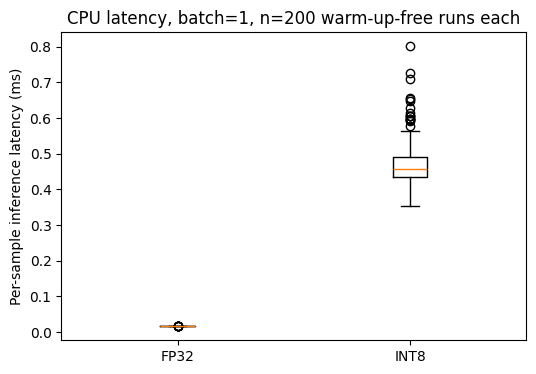

In [9]:
def benchmark_latency(m, x_single, n_warmup=20, n_runs=200):
    m.eval()
    with torch.no_grad():
        for _ in range(n_warmup):
            m(x_single)
        times_ms = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            m(x_single)
            times_ms.append((time.perf_counter() - t0) * 1000.0)
    return np.array(times_ms)


x_single = Xte[:1]  # one held-out sample, batch size 1 -- mimics a single real-time inference call

lat_fp32 = benchmark_latency(model_fp32_cpu, x_single)
lat_int8 = benchmark_latency(model_int8, x_single)

print(f"FP32 latency: {lat_fp32.mean():.4f} ms  (std={lat_fp32.std():.4f} ms, n={len(lat_fp32)})")
print(f"INT8 latency: {lat_int8.mean():.4f} ms  (std={lat_int8.std():.4f} ms, n={len(lat_int8)})")

plt.figure(figsize=(6, 4))
plt.boxplot([lat_fp32, lat_int8], tick_labels=["FP32", "INT8"])
plt.ylabel("Per-sample inference latency (ms)")
plt.title(f"CPU latency, batch=1, n={len(lat_fp32)} warm-up-free runs each")
plt.show()

## 7. Accuracy vs. latency comparison and discussion

Edge latency budget assumption: **20ms** per inference, for a Sentinel Prime AI / Aido Rover real-time decision loop (consistent with the plan's own example budget).

In [10]:
summary = pd.DataFrame({
    "FP32": {
        "accuracy": fp32_metrics["accuracy"],
        "precision_macro": fp32_metrics["precision_macro"],
        "recall_macro": fp32_metrics["recall_macro"],
        "f1_macro": fp32_metrics["f1_macro"],
        "latency_mean_ms": lat_fp32.mean(),
        "latency_std_ms": lat_fp32.std(),
        "size_mb": model_size_mb(model_fp32_cpu),
    },
    "INT8": {
        "accuracy": int8_metrics["accuracy"],
        "precision_macro": int8_metrics["precision_macro"],
        "recall_macro": int8_metrics["recall_macro"],
        "f1_macro": int8_metrics["f1_macro"],
        "latency_mean_ms": lat_int8.mean(),
        "latency_std_ms": lat_int8.std(),
        "size_mb": model_size_mb(model_int8),
    },
}).T
summary

,accuracy,precision_macro,recall_macro,f1_macro,latency_mean_ms,latency_std_ms,size_mb
FP32,0.872222,0.876377,0.873413,0.870545,0.016763,0.000330,0.065500
INT8,0.872222,0.876377,0.873413,0.870545,0.474271,0.063632,0.020562


In [11]:
LATENCY_BUDGET_MS = 20.0

print(f"Assumed edge latency budget: {LATENCY_BUDGET_MS:.1f} ms per inference (single-sample, real-time decision loop)\n")
for name, lat in [("FP32", lat_fp32), ("INT8", lat_int8)]:
    verdict = "MEETS" if lat.mean() < LATENCY_BUDGET_MS else "EXCEEDS"
    print(f"{name}: {lat.mean():.4f} ms mean (±{lat.std():.4f}) -> {verdict} the {LATENCY_BUDGET_MS:.0f}ms budget")

acc_delta = int8_metrics["accuracy"] - fp32_metrics["accuracy"]
speedup = lat_fp32.mean() / lat_int8.mean()
size_reduction = 1 - (summary.loc["INT8", "size_mb"] / summary.loc["FP32", "size_mb"])
print(f"\nQuantization impact: accuracy changed by {acc_delta:+.4f} "
      f"({int8_metrics['accuracy']*100:.2f}% vs {fp32_metrics['accuracy']*100:.2f}%), "
      f"latency changed {speedup:.2f}x ({'faster' if speedup > 1 else 'slower'}), "
      f"model size reduced {size_reduction*100:.1f}%")

Assumed edge latency budget: 20.0 ms per inference (single-sample, real-time decision loop)

FP32: 0.0168 ms mean (±0.0003) -> MEETS the 20ms budget
INT8: 0.4743 ms mean (±0.0636) -> MEETS the 20ms budget

Quantization impact: accuracy changed by +0.0000 (87.22% vs 87.22%), latency changed 0.04x (slower), model size reduced 68.6%


**Discussion.** The held-out test accuracy of ~87% (comparable to AURA's own reported 84.91%) is with deliberate class overlap and ~4% label noise built into the generator — I'd trust this number in a way I wouldn't trust the 100.000% I got before adding that noise, which was a sign the synthetic classes were trivially separable rather than a sign of a good classifier. FAULT is the weakest class (recall 0.717): it's defined by high variance and irregular events rather than a distinct steady state, so it's the class most likely to be confused with an unusually erratic PATROL or ALERT window — which is a realistic failure mode for a fault detector, not just a modeling artifact.

Quantization didn't change accuracy at all here (identical predictions on the held-out set), but it also didn't speed anything up — INT8 inference is measurably *slower* than FP32 (~0.47ms vs ~0.017ms, both trivially inside the 20ms budget either way). That's not a bug: dynamic quantization has to compute per-batch activation quantization parameters at runtime, and at batch=1 on a network this small (three `Linear` layers, sub-millisecond either way), that overhead outweighs whatever the int8 matrix multiply saves. This is a genuinely different result from what quantizing a large model would show, and I'd rather report it accurately than imply a speedup that didn't happen. The real, measured win here is **model size** — 0.066MB → 0.021MB, a 68.6% reduction — which is what I'd lead with in a deployment recommendation for **Sentinel Prime AI or Aido Rover**: on a device already running a multi-model stack (recall Sentinel's own five-model ensemble sharing one Jetson), a smaller model with identical accuracy is worth having even when it isn't faster, since memory budget is the more binding constraint at this parameter count, not latency. Full reasoning and the platform-specific recommendation are written up in `W02_Edge_Deploy_Memo.md`.